# Colab



In [8]:
# Colab

데이터 과학에 필요한 라이브러리들이 웬만한거 다 설치 되어있습니다.
파이썬이나 라이브러리 설치 안하고 브라우저에서 꿀 먹!

SyntaxError: invalid syntax (835783155.py, line 3)

In [9]:
import pandas as pd # 판다스
import sklearn  # 사이킷 런

In [10]:
sklearn.__version__

'1.8.0'

In [11]:
pd.__version__

'3.0.3'

In [12]:
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7,
                31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5,
                34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0,
                38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0,
                500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0,
                610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0,
                714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2,
                12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2,
                13.4, 12.2, 19.7, 19.9]

In [13]:
print("도미 : ", len(bream_length) )
print("빙어 : ", len(smelt_length) )

도미 :  35
빙어 :  14


# 시각화

In [15]:
import matplotlib.pyplot as plt

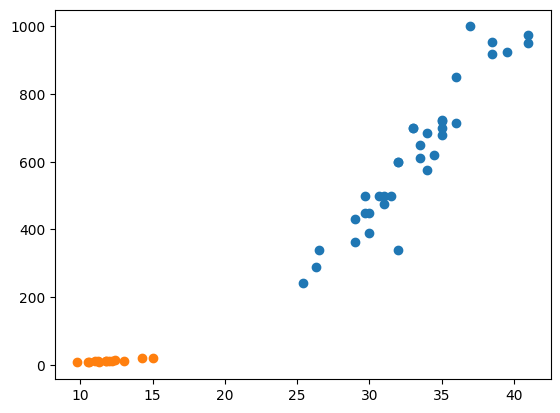

In [14]:
plt.scatter(bream_length, bream_weight) # 도미
plt.scatter(smelt_length, smelt_weight) # 빙어
plt.show()

## 데이터 전처리

In [ ]:
# 데이터 합치기
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

In [17]:
length

[25.4,
 26.3,
 26.5,
 29.0,
 29.0,
 29.7,
 29.7,
 30.0,
 30.0,
 30.7,
 31.0,
 31.0,
 31.5,
 32.0,
 32.0,
 32.0,
 33.0,
 33.0,
 33.5,
 33.5,
 34.0,
 34.0,
 34.5,
 35.0,
 35.0,
 35.0,
 35.0,
 36.0,
 36.0,
 37.0,
 38.5,
 38.5,
 39.5,
 41.0,
 41.0,
 9.8,
 10.5,
 10.6,
 11.0,
 11.2,
 11.3,
 11.8,
 11.8,
 12.0,
 12.2,
 12.4,
 13.0,
 14.3,
 15.0]

In [30]:
len(length)

49

In [18]:
# Feature 특성 정보를 묶었습니다.
# 길이, 무게
fish_data = [[l, w] for l, w in zip(length, weight)]
fish_data[0:5]

[[25.4, 242.0], [26.3, 290.0], [26.5, 340.0], [29.0, 363.0], [29.0, 430.0]]

In [19]:
# Label 정답 정보  도미 : 1, 빙어 : 0
fish_target = [1] * 35 + [0] * 14
print(fish_target)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [20]:
# 데이터 쪼개기
from sklearn.model_selection import train_test_split

In [21]:
train_x, test_x, train_y, test_y = train_test_split(fish_data, fish_target, random_state=42)

* train set : 모델이 학습하는 데이터
* test set : 모델이 보지 못하는 데이터
* random하게 데이터를 나누어서 쪼갠다. (이렇게 하지 않으면, 처음있는거는 다 도미, 나중은 다 빙어)
* 기본 비율은 75 | 25

In [22]:
len(train_x), len(train_y), len(test_x)

(36, 36, 13)

## 모델 가져오기

In [23]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
kn 

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
# 학습
kn.fit(train_x, train_y)  # KNN 분류기로 학습 (학습용 데이터만)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## 예측

In [25]:
kn.predict([[30, 600]]) # 예측의 입력값은 Matrix
# 반환 값은 ndarray
# 1 -> 도미. 해당 모델로 예측할 떈 도미!

array([1])

In [26]:
kn.predict([[15, 50]]) # 빙어로 예측
# 새로운 데이터가 들어오면, 모델에서 예측하여 target(Y, label)을 예측한다.

array([0])

## 평가

In [27]:
kn.score(test_x, test_y) # X값과 Y 값을 입력
# 정확도를 반환한다.
# Accuracy 1.0 => 13개 데이터 모두 100%의 정확도를 가지는 모델

1.0

In [28]:
test_y

[1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [29]:
from sklearn.neighbors import KNeighborsClassifier

# 1. 모델 생성
kn = KNeighborsClassifier(n_neighbors=49)  # 기본 k=5

# 2. 학습 (데이터 저장)
kn.fit(fish_data, fish_target)

# 3. 예측
result = kn.predict([[30, 600]])
print(result)   # [1] → 도미

# 4. 정확도
score = kn.score(fish_data, fish_target)
print(score)    # 1.0

[1]
0.7142857142857143


## 샘플링

In [34]:
# 학습 데이터, 테스트 데이터 나눌거야..
len(fish_data) # 49니까 36:13으로 나눌거야.
train_input = fish_data[:36]  # 앞에꺼 36개 학습데이터로 쓸게 
len(train_input)
test_input = fish_data[36:] # 36번째 이후거 테스트 데이터로 쓸게
len(test_input)

13

### 샘플링 편향
- sampling bias
- 우리 데이터는 앞쪽은 모두 도미, 뒷쪽은 모두 빙어
- 도미로 100% 학습하면 => 예측결과도 무조건 도미, 테스트는 무조건 빙어 => 다 틀림.
- 데이터 샘플링 시는 편향을 피해야 함.
  - scikit-learn에서 함수 씁시다!

In [42]:
# 브로드 캐스팅 : 사칙 연산을 모든 행이나 모든 열로 확장해서 수행하는 기능
import numpy as np
print(len(fish_data * 100))  # 리스트는 데이터의 길이를 더하거나 곱해서 길이가 늘어난다.
fish_ndarr = np.array(fish_data) 
print(len(fish_ndarr * 100))  # numpy ndarray는 브로드캐스팅을 수행

4900
49


## 스케일링

- 스케일
- 표준화
- 스케일이 다른 특성(feature)은 어떻게 처리하는가?